In [18]:
import transformers
transformers.__version__

'4.30.2'

In [7]:
!pip install transformers==4.30.2

In [8]:
import transformers
transformers.__version__

'4.30.2'

In [2]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [37]:
import os
import random
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

DATASET_PATH = "/kaggle/input/ai-generated-images-vs-real-images/"

In [23]:
print(f"Directories in the Dataset: {os.listdir(DATASET_PATH)}")
print(f"Labels: {os.listdir(os.path.join(DATASET_PATH, 'train'))}")
print(f"Number of Samples in label 'real': {len(os.listdir(os.path.join(DATASET_PATH, 'train/real')))}")
print(f"Number of Samples in label 'fake': {len(os.listdir(os.path.join(DATASET_PATH, 'train/fake')))}")

Directories in the Dataset: ['test', 'train']
Labels: ['fake', 'real']
Number of Samples in label 'real': 24000
Number of Samples in label 'fake': 24000


In [10]:
real_path = os.path.join(DATASET_PATH, "train/real")
fake_path = os.path.join(DATASET_PATH, "train/fake")

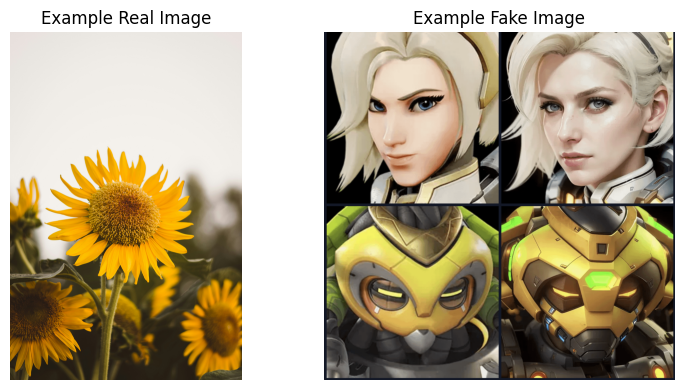

In [36]:
# Pick random samples from each folder
fake_sample_path = os.path.join(fake_path, random.choice(os.listdir(fake_path)))
real_sample_path = os.path.join(real_path, random.choice(os.listdir(real_path)))

# Open images
fake_img = Image.open(fake_sample_path)
real_img = Image.open(real_sample_path)

# Plot side by side
plt.figure(figsize=(8, 4))

# Real image (left)
plt.subplot(1, 2, 1)
plt.imshow(real_img)
plt.axis("off")
plt.title("Example Real Image")

# Fake image (right)
plt.subplot(1, 2, 2)
plt.imshow(fake_img)
plt.axis("off")
plt.title("Example Fake Image")

plt.tight_layout()
plt.show()

In [39]:
real_images = [(os.path.join(real_path, f), 1) for f in os.listdir(real_path)]
fake_images = [(os.path.join(fake_path, f), 0) for f in os.listdir(fake_path)]

df = pd.DataFrame(real_images + fake_images, columns=["filepath", "label"])
print(df.head(3))
print(df.tail(3))
print(df["label"].value_counts())

                                            filepath  label
0  /kaggle/input/ai-generated-images-vs-real-imag...      1
1  /kaggle/input/ai-generated-images-vs-real-imag...      1
2  /kaggle/input/ai-generated-images-vs-real-imag...      1
                                                filepath  label
47997  /kaggle/input/ai-generated-images-vs-real-imag...      0
47998  /kaggle/input/ai-generated-images-vs-real-imag...      0
47999  /kaggle/input/ai-generated-images-vs-real-imag...      0
label
1    24000
0    24000
Name: count, dtype: int64


# FINETUNE: openai/clip-vit-base-patch32

In [26]:
# Environment Setup and Imports
import os
import random
import numpy as np
from PIL import Image, ImageFile

import torch
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from tqdm import tqdm
from torch import nn, optim
from torch.optim import Adam, AdamW

from transformers import CLIPModel, CLIPImageProcessor

# Fix for truncated images loading error
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Device setup
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)

# Hyperparameters
EPOCHS = 3
BATCH_SIZE = 32
LEARNING_RATE = 1e-4

# Dataset path
DATASET_PATH = "/kaggle/input/ai-generated-images-vs-real-images"

Using device: cuda


In [27]:
# Data Preparation with CLIP Image Processor and ImageFolder

# Load CLIP image processor for correct pre-processing
clip_model_name = "openai/clip-vit-base-patch32"
processor = CLIPImageProcessor.from_pretrained(clip_model_name)

image_size = (
    processor.size.get("shortest_edge", 224)
    if isinstance(processor.size, dict)
    else processor.size
)

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])

val_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])

# def is_valid_image(path):
#     """Checks if a file is a valid, openable image."""
#     try:
#         with Image.open(path) as img:
#             img.verify() # Verify the image data
#         return True
#     except Exception as e:
#         print(f"Skipping corrupt image: {path}, error: {e}")
#         return False

# train_dataset = datasets.ImageFolder(
#     root=f"{DATASET_PATH}/train", 
#     transform=train_transform,
#     is_valid_file=is_valid_image
# )

# val_dataset = datasets.ImageFolder(
#     root=f"{DATASET_PATH}/test", 
#     transform=val_transform,
#     is_valid_file=is_valid_image
# )

train_dataset = datasets.ImageFolder(
    root=f"{DATASET_PATH}/train", 
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=f"{DATASET_PATH}/test", 
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=4, 
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Classes: {train_dataset.class_to_idx}")

Train samples: 48000
Val samples: 12000
Classes: {'fake': 0, 'real': 1}


In [28]:
# Define Model Architecture with classification head (no sigmoid)

class CLIPImageClassifier(nn.Module):
    def __init__(self, clip_model_name="openai/clip-vit-base-patch32"):
        super(CLIPImageClassifier, self).__init__()
        self.clip = CLIPModel.from_pretrained(clip_model_name)
        
        # Freeze CLIP parameters so we only train the classifier head
        for param in self.clip.parameters():
            param.requires_grad = False
        
        self.classifier = nn.Sequential(
            nn.Linear(self.clip.config.vision_config.hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1),  # Single output logit for binary classification
        )
    
    def forward(self, pixel_values):
        vision_outputs = self.clip.vision_model(pixel_values=pixel_values)
        image_features = vision_outputs.pooler_output
        logits = self.classifier(image_features)
        return logits.squeeze(-1)  # Output shape: [batch_size]

model = CLIPImageClassifier().to(DEVICE)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

In [29]:
# Loss Function and Optimizer

criterion = nn.BCEWithLogitsLoss()  # Combines sigmoid + BCE loss, more stable
optimizer = optim.Adam(model.classifier.parameters(), lr=LEARNING_RATE)  # Only train classifier

# optimizer = torch.optim.AdamW(
#     model.classifier.parameters(),
#     lr=LEARNING_RATE,
#     weight_decay=1e-4  # mild, safe since Dropout(0.5) already regularizes
# )

In [30]:
# Train for one epoch

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(dataloader, desc="Training"):
        images = images.to(device)
        labels = labels.to(device).float()  # float required for BCEWithLogitsLoss
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    return running_loss / len(dataloader)

In [31]:
# Validate model accuracy

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Evaluating"):
            images = images.to(device)
            labels = labels.to(device).float()
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    avg_loss = running_loss / len(dataloader)
    accuracy = correct / total
    return avg_loss, accuracy

In [59]:
# Evaluate BEFORE fine-tuning
initial_val_loss, initial_val_acc = evaluate(model, val_loader, criterion, DEVICE)
print(f"Initial Validation Loss: {initial_val_loss:.4f}")
print(f"Initial Validation Accuracy: {initial_val_acc:.4f}")

Evaluating:   6%|▌         | 23/375 [00:11<02:13,  2.63it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating:  15%|█▍        | 55/375 [00:24<02:26,  2.18it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating:  18%|█▊        | 69/375 [00:28<01:35,  3.20it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating: 100%|██████████| 375/375 [06:44<00:00,  1.08s/it]

Initial Validation Loss: 0.6818
Initial Validation Accuracy: 0.5272


In [ ]:
# Evaluation Results BEFORE Finetuning

# Initial Validation Loss: 0.6818
# Initial Validation Accuracy: 0.5272

In [32]:
# Full training + validation loop

best_val_accuracy = 0.0

for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{EPOCHS} ---")
    
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
    
    print(f"Epoch {epoch+1} Summary:")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Validation Loss: {val_loss:.4f}")
    print(f"  Validation Accuracy: {val_acc:.4f}")
    
    # Save model checkpoint if improvement in validation accuracy
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(model.state_dict(), "best_clip_classifier.pth")
        print(f"🎉 New best model saved! Accuracy: {val_acc:.4f} at epoch {epoch+1}")

print("\nTraining complete.")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")


--- Epoch 1/3 ---


Training:   1%|▏         | 22/1500 [00:32<33:32,  1.36s/it] /usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:   6%|▋         | 96/1500 [01:53<25:12,  1.08s/it]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Training:  12%|█▏        | 179/1500 [03:23<11:53,  1.85it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (98058240 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Training:  13%|█▎        | 194/1500 [03:43<27:45,  1.28s/it]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (161087488 pixels) exceeds limit of 89478485 pixels, could be decompression bom

Epoch 1 Summary:
  Train Loss: 0.2010
  Validation Loss: 0.1417
  Validation Accuracy: 0.9450
🎉 New best model saved! Accuracy: 0.9450 at epoch 1

--- Epoch 2/3 ---


Training:   1%|          | 14/1500 [00:21<34:17,  1.38s/it] /usr/local/lib/python3.11/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (98806617 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Training:   5%|▌         | 79/1500 [01:33<20:08,  1.18it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  11%|█         | 165/1500 [03:09<15:26,  1.44it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  15%|█▌        | 231/1500 [04:19<28:27,  1.35s/it]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (99991727 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(

Epoch 2 Summary:
  Train Loss: 0.1360
  Validation Loss: 0.1250
  Validation Accuracy: 0.9538
🎉 New best model saved! Accuracy: 0.9538 at epoch 2

--- Epoch 3/3 ---


Training:   4%|▎         | 53/1500 [00:58<20:03,  1.20it/s] /usr/local/lib/python3.11/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (107184040 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Training:   5%|▌         | 82/1500 [01:33<19:06,  1.24it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:   7%|▋         | 99/1500 [01:52<18:24,  1.27it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96012000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Training:  10%|▉         | 147/1500 [02:47<29:02,  1.29s/it]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(

Epoch 3 Summary:
  Train Loss: 0.1188
  Validation Loss: 0.1171
  Validation Accuracy: 0.9564
🎉 New best model saved! Accuracy: 0.9564 at epoch 3

Training complete.
Best validation accuracy: 0.9564


In [ ]:
# Evaluation Results AFTER Finetuning

# Epoch 1 Summary:
#   Train Loss: 0.2010
#   Validation Loss: 0.1417
#   Validation Accuracy: 0.9450

# Epoch 2 Summary:
#   Train Loss: 0.1360
#   Validation Loss: 0.1250
#   Validation Accuracy: 0.9538

# Epoch 3 Summary:
#   Train Loss: 0.1188
#   Validation Loss: 0.1171
#   Validation Accuracy: 0.9564

# FINETUNE: facebook/convnextv2-base-22k-224

In [60]:
# Environment Setup and Imports
import os
import random
import numpy as np
from PIL import Image, ImageFile

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
from torch import nn, optim
from torch.optim import Adam, AdamW

from transformers import AutoImageProcessor, ConvNextV2Model

ImageFile.LOAD_TRUNCATED_IMAGES = True

# Device setup
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)

# Hyperparameters
EPOCHS = 3
BATCH_SIZE = 32
LEARNING_RATE = 1e-4

# Dataset path
DATASET_PATH = "/kaggle/input/ai-generated-images-vs-real-images"

Using device: cuda


In [61]:
# Data Preparation with transforms and processor
model_name = "facebook/convnextv2-base-22k-224"
processor = AutoImageProcessor.from_pretrained(model_name)

image_size = (
    processor.size.get("shortest_edge", 224)
    if isinstance(processor.size, dict)
    else processor.size
)

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),  # augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])

val_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
])

# def is_valid_image(path):
#     """Checks if a file is a valid, openable image."""
#     try:
#         with Image.open(path) as img:
#             img.verify() # Verify the image data
#         return True
#     except Exception as e:
#         print(f"Skipping corrupt image: {path}, error: {e}")
#         return False

# train_dataset = datasets.ImageFolder(
#     root=f"{DATASET_PATH}/train", 
#     transform=train_transform,
#     is_valid_file=is_valid_image
# )

# val_dataset = datasets.ImageFolder(
#     root=f"{DATASET_PATH}/test", 
#     transform=val_transform,
#     is_valid_file=is_valid_image
# )

train_dataset = datasets.ImageFolder(
    root=f"{DATASET_PATH}/train", 
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=f"{DATASET_PATH}/test", 
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=4, 
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Classes: {train_dataset.class_to_idx}")

preprocessor_config.json:   0%|          | 0.00/352 [00:00<?, ?B/s]

Skipping corrupt image: /kaggle/input/ai-generated-images-vs-real-images/test/real/5879.jpg, error: Truncated File Read
Train samples: 48000
Val samples: 11999
Classes: {'fake': 0, 'real': 1}


In [62]:
# Model with custom head
class ConvNeXtV2ImageClassifier(nn.Module):
    def __init__(self, model_name="facebook/convnextv2-base-22k-224"):
        super().__init__()
        self.backbone = ConvNextV2Model.from_pretrained(model_name)
        
        # Freeze backbone if desired
        for p in self.backbone.parameters():
            p.requires_grad = False

        hidden_size = self.backbone.config.hidden_sizes[-1]

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1),
        )
    
    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values)
        feats = outputs.last_hidden_state.mean(dim=(-2, -1))  # global average pooling
        logits = self.classifier(feats)
        return logits.squeeze(-1)

model = ConvNeXtV2ImageClassifier().to(DEVICE)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/355M [00:00<?, ?B/s]

Some weights of the model checkpoint at facebook/convnextv2-base-22k-224 were not used when initializing ConvNextV2Model: ['classifier.bias', 'classifier.weight']
- This IS expected if you are initializing ConvNextV2Model from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing ConvNextV2Model from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [63]:
# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=LEARNING_RATE)

# optimizer = torch.optim.AdamW(
#     model.classifier.parameters(),
#     lr=LEARNING_RATE,
#     weight_decay=1e-4  # mild, safe since Dropout(0.5) already regularizes
# )

In [64]:
# Training for one epoch
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for pixel_values, labels in tqdm(dataloader, desc="Training"):
        pixel_values = pixel_values.to(device)
        labels = labels.to(device).float()
        optimizer.zero_grad()
        outputs = model(pixel_values)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

In [65]:
# Validation
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for pixel_values, labels in tqdm(dataloader, desc="Evaluating"):
            pixel_values = pixel_values.to(device)
            labels = labels.to(device).float()
            outputs = model(pixel_values)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(dataloader), correct / total

In [66]:
# Evaluate BEFORE fine-tuning
initial_val_loss, initial_val_acc = evaluate(model, val_loader, criterion, DEVICE)
print(f"Initial Validation Loss: {initial_val_loss:.4f}")
print(f"Initial Validation Accuracy: {initial_val_acc:.4f}")

Evaluating:   6%|▌         | 23/375 [00:13<02:47,  2.10it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating:  15%|█▍        | 55/375 [00:29<02:41,  1.98it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating:  17%|█▋        | 63/375 [00:33<02:40,  1.94it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating: 100%|██████████| 375/375 [07:53<00:00,  1.26s/it]

Initial Validation Loss: 0.7558
Initial Validation Accuracy: 0.4342


In [ ]:
# Evaluation Results BEFORE Finetuning

# Initial Validation Loss: 0.7558
# Initial Validation Accuracy: 0.4342

In [ ]:
# Full training loop
best_acc = 0.0
for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{EPOCHS} ---")
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
    print(f"Epoch {epoch+1} summary:")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss: {val_loss:.4f}")
    print(f"  Val Accuracy: {val_acc:.4f}")
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_convnextv2.pth")
        print(f"🎉 New best model saved! Accuracy: {val_acc:.4f}")

print(f"\nTraining complete. Best validation accuracy: {best_acc:.4f}")


--- Epoch 1/5 ---


Training:   1%|▏         | 20/1500 [00:25<16:31,  1.49it/s] /usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  11%|█▏        | 169/1500 [03:30<16:33,  1.34it/s] /usr/local/lib/python3.11/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (161087488 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Training:  14%|█▍        | 208/1500 [04:18<18:32,  1.16it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  30%|███       | 454/1500 [09:12<16:24,  1.06it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  31%|███       

Epoch 1 summary:
  Train Loss: 0.2996
  Val Loss: 0.2234
  Val Accuracy: 0.9068
🎉 New best model saved! Accuracy: 0.9068

--- Epoch 2/5 ---


Training:   2%|▏         | 36/1500 [00:51<25:12,  1.03s/it] /usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:   7%|▋         | 100/1500 [02:19<26:10,  1.12s/it] /usr/local/lib/python3.11/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Training:  25%|██▍       | 368/1500 [08:18<16:32,  1.14it/s]  /usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  30%|███       | 451/1500 [10:11<17:30,  1.00s/it]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96012000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.w

Epoch 2 summary:
  Train Loss: 0.2147
  Val Loss: 0.1944
  Val Accuracy: 0.9217
🎉 New best model saved! Accuracy: 0.9217

--- Epoch 3/5 ---


Training:   1%|          | 8/1500 [00:13<28:48,  1.16s/it]  /usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:   2%|▏         | 36/1500 [00:51<22:09,  1.10it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (98058240 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Training:   4%|▎         | 54/1500 [01:18<34:45,  1.44s/it]  /usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  15%|█▌        | 226/1500 [05:08<24:04,  1.13s/it]  /usr/local/lib/python3.11/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (90671520 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.wa

Epoch 3 summary:
  Train Loss: 0.1845
  Val Loss: 0.1834
  Val Accuracy: 0.9267
🎉 New best model saved! Accuracy: 0.9267

--- Epoch 4/5 ---


Training:   3%|▎         | 48/1500 [01:14<30:14,  1.25s/it]  /usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:   3%|▎         | 52/1500 [01:20<26:18,  1.09s/it]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (161087488 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Training:   6%|▋         | 96/1500 [02:21<26:23,  1.13s/it]  /usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:   8%|▊         | 123/1500 [02:58<22:05,  1.04it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (96012000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.wa

In [ ]:
# Evaluation Results AFTER Finetuning

# Epoch 1 summary:
#   Train Loss: 0.2996
#   Val Loss: 0.2234
#   Val Accuracy: 0.9068

# Epoch 2 summary:
#   Train Loss: 0.2147
#   Val Loss: 0.1944
#   Val Accuracy: 0.9217

# Epoch 3 summary:
#   Train Loss: 0.1845
#   Val Loss: 0.1834
#   Val Accuracy: 0.9267


# FINETUNE: timm/maxvit_base_tf_224.in21k

In [33]:
# Environment Setup and Imports
import os
import random
import numpy as np
from PIL import Image, ImageFile

import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from tqdm import tqdm
from torch import nn, optim

import timm
import timm.data

# Fix for truncated images loading error
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Device setup
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)

# Hyperparameters
EPOCHS = 3
BATCH_SIZE = 32
LEARNING_RATE = 1e-4

# Dataset path
DATASET_PATH = "/kaggle/input/ai-generated-images-vs-real-images"

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Using device: cuda


In [34]:
# Data Preparation with timm transforms and ImageFolder

model_name = "maxvit_base_tf_224.in21k"
backbone = timm.create_model(model_name, pretrained=True, num_classes=0)

# Get data config (mean, std, input size, etc.) for transforms
data_config = timm.data.resolve_model_data_config(backbone)

train_transform = timm.data.create_transform(
    **data_config,
    is_training=True,
)

val_transform = timm.data.create_transform(
    **data_config,
    is_training=False,
)

# def is_valid_image(path):
#     """Checks if a file is a valid, openable image."""
#     try:
#         with Image.open(path) as img:
#             img.verify()  # Verify the image data
#         return True
#     except Exception as e:
#         print(f"Skipping corrupt image: {path}, error: {e}")
#         return False


# train_dataset = datasets.ImageFolder(
#     root=f"{DATASET_PATH}/train",
#     transform=train_transform,
#     is_valid_file=is_valid_image,
# )

# val_dataset = datasets.ImageFolder(
#     root=f"{DATASET_PATH}/test",
#     transform=val_transform,
#     is_valid_file=is_valid_image,
# )

train_dataset = datasets.ImageFolder(
    root=f"{DATASET_PATH}/train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=f"{DATASET_PATH}/test",
    transform=val_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Classes: {train_dataset.class_to_idx}")

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Train samples: 48000
Val samples: 12000
Classes: {'fake': 0, 'real': 1}


In [35]:
# Define Model Architecture with MaxViT backbone + classification head

class MaxViTClassifier(nn.Module):
    def __init__(self, model_name="maxvit_base_tf_224.in21k"):
        super(MaxViTClassifier, self).__init__()
        # Load timm model as backbone without classifier head
        self.backbone = timm.create_model(model_name, pretrained=True, num_classes=0)
        
        # Freeze backbone parameters (optional - can unfreeze if full fine-tuning desired)
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        # Get feature dimension from backbone's feature_info at last layer
        feature_dim = self.backbone.feature_info[-1]['num_chs']
        
        # Classification head for binary classification
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1),  # Single output logit for binary classification
        )
    
    def forward(self, x):
        features = self.backbone(x)  # Output: [batch_size, feature_dim]
        logits = self.classifier(features)
        return logits.squeeze(-1)  # Shape: [batch_size]

model = MaxViTClassifier().to(DEVICE)

In [36]:
# Loss and optimizer

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=LEARNING_RATE)

In [37]:
# Train for one epoch

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(dataloader, desc="Training"):
        images = images.to(device)
        labels = labels.to(device).float()  # float required for BCEWithLogitsLoss
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    return running_loss / len(dataloader)

In [38]:
# Validate model accuracy

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Evaluating"):
            images = images.to(device)
            labels = labels.to(device).float()
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    avg_loss = running_loss / len(dataloader)
    accuracy = correct / total
    return avg_loss, accuracy

In [7]:
# Evaluate BEFORE fine-tuning
initial_val_loss, initial_val_acc = evaluate(model, val_loader, criterion, DEVICE)
print(f"Initial Validation Loss: {initial_val_loss:.4f}")
print(f"Initial Validation Accuracy: {initial_val_acc:.4f}")

Evaluating:   6%|▌         | 22/375 [00:18<04:12,  1.40it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating:  15%|█▍        | 55/375 [00:43<04:09,  1.28it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating:  17%|█▋        | 62/375 [00:48<04:10,  1.25it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating: 100%|██████████| 375/375 [11:24<00:00,  1.83s/it]

Initial Validation Loss: 0.6936
Initial Validation Accuracy: 0.4984


In [ ]:
# Evaluation Results BEFORE Finetuning

# Initial Validation Loss: 0.6936
# Initial Validation Accuracy: 0.4984

In [39]:
# Full training + validation loop

best_val_accuracy = 0.0

for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{EPOCHS} ---")
    
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
    
    print(f"Epoch {epoch+1} Summary:")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Validation Loss: {val_loss:.4f}")
    print(f"  Validation Accuracy: {val_acc:.4f}")
    
    # Save model checkpoint if improvement in validation accuracy
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(model.state_dict(), "best_maxvit_in21k_classifier.pth")
        print(f"🎉 New best model saved! Accuracy: {val_acc:.4f} at epoch {epoch+1}")

print("\nTraining complete.")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")


--- Epoch 1/3 ---


Training:   4%|▍         | 57/1500 [01:19<25:45,  1.07s/it] /usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:   6%|▋         | 97/1500 [02:12<24:58,  1.07s/it]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (107184040 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Training:  10%|▉         | 147/1500 [03:26<28:36,  1.27s/it] /usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  12%|█▏        | 186/1500 [04:16<21:30,  1.02it/s]  /usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  17%|█▋       

Epoch 1 Summary:
  Train Loss: 0.4515
  Validation Loss: 0.3352
  Validation Accuracy: 0.8628
🎉 New best model saved! Accuracy: 0.8628 at epoch 1

--- Epoch 2/3 ---


Training:  12%|█▏        | 180/1500 [04:12<19:19,  1.14it/s] /usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  20%|█▉        | 297/1500 [06:55<20:11,  1.01s/it]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  28%|██▊       | 425/1500 [09:54<34:06,  1.90s/it]  /usr/local/lib/python3.11/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (161087488 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Training:  30%|███       | 457/1500 [10:34<17:22,  1.00it/s]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (98806617 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.

Epoch 2 Summary:
  Train Loss: 0.3372
  Validation Loss: 0.2997
  Validation Accuracy: 0.8740
🎉 New best model saved! Accuracy: 0.8740 at epoch 2

--- Epoch 3/3 ---


Training:   1%|          | 8/1500 [00:14<27:58,  1.12s/it]  /usr/local/lib/python3.11/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (107184040 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Training:  10%|█         | 152/1500 [03:29<36:19,  1.62s/it] /usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  12%|█▏        | 181/1500 [04:11<36:16,  1.65s/it]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (98058240 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Training:  13%|█▎        | 199/1500 [04:33<24:10,  1.12s/it]/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.wa

Epoch 3 Summary:
  Train Loss: 0.3185
  Validation Loss: 0.2905
  Validation Accuracy: 0.8772
🎉 New best model saved! Accuracy: 0.8772 at epoch 3

Training complete.
Best validation accuracy: 0.8772


In [ ]:
# Evaluation Results AFTER Finetuning

# Epoch 1 Summary:
#   Train Loss: 0.4515
#   Validation Loss: 0.3352
#   Validation Accuracy: 0.8628

# Epoch 2 Summary:
#   Train Loss: 0.3372
#   Validation Loss: 0.2997
#   Validation Accuracy: 0.8740

# Epoch 3 Summary:
#   Train Loss: 0.3185
#   Validation Loss: 0.2905
#   Validation Accuracy: 0.8772

In [ ]:
# # Load Finetuned Model
# FINETUNED_MODEL_NAME = "best_convnextv2.pth"

# # Step 1: Recreate the model architecture
# model = ConvNeXtV2ImageClassifier().to(DEVICE)

# # Step 2: Load the saved weights
# model.load_state_dict(torch.load(f"/kaggle/working/{FINETUNED_MODEL_NAME}", map_location=DEVICE))

# # Step 3: Set model to evaluation mode
# model.eval()

# # Step 4: Evaluate on validation set
# val_loss, val_accuracy = evaluate(model, val_loader, criterion, DEVICE)

# print(f"Loaded Model Validation Loss: {val_loss:.4f}")
# print(f"Loaded Model Validation Accuracy: {val_accuracy:.4f}")